<a href="https://colab.research.google.com/github/MarinPedro/ThermalProject2026_HOCV/blob/main/SCV_P.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Creamos una carpeta donde guardaremos nuestros datos

In [ ]:
%mkdir -p /content/lwhsi_202104
%cd /content/lwhsi_202104

/content/lwhsi_202104


Cargamos algunos archivos del DARPA Invisible Headlights 202104

In [ ]:
!pip install spectral
!pip install awscli -q
!aws s3 sync --no-sign-request \
  --exclude "*" \
  --include "*Path0_DistStA*LWHSI*" \
  s3://ihdataset-01/IHTest_202104_DistStA/ /content/lwhsi_202104/

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.2/215.2 kB 10.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for spectral: filename=spectral-0.25-py3-none-any.whl size=242858 sha256=00fe0c9b278fc5cd9546d11adafe70ae6a7800fad71999ecc070b4e3f80a51bf
  Stored in directory: /root/.cache/pip/wheels/0e/86/f2/f215d05f41af2059193a22339d0b694c3e2ca6bbb6fe58bd5f
Successfully built spectral
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.5/15.5 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 5.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
downl

Ploteando las imágenes

/tmp/ipykernel_1482/4125044562.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)


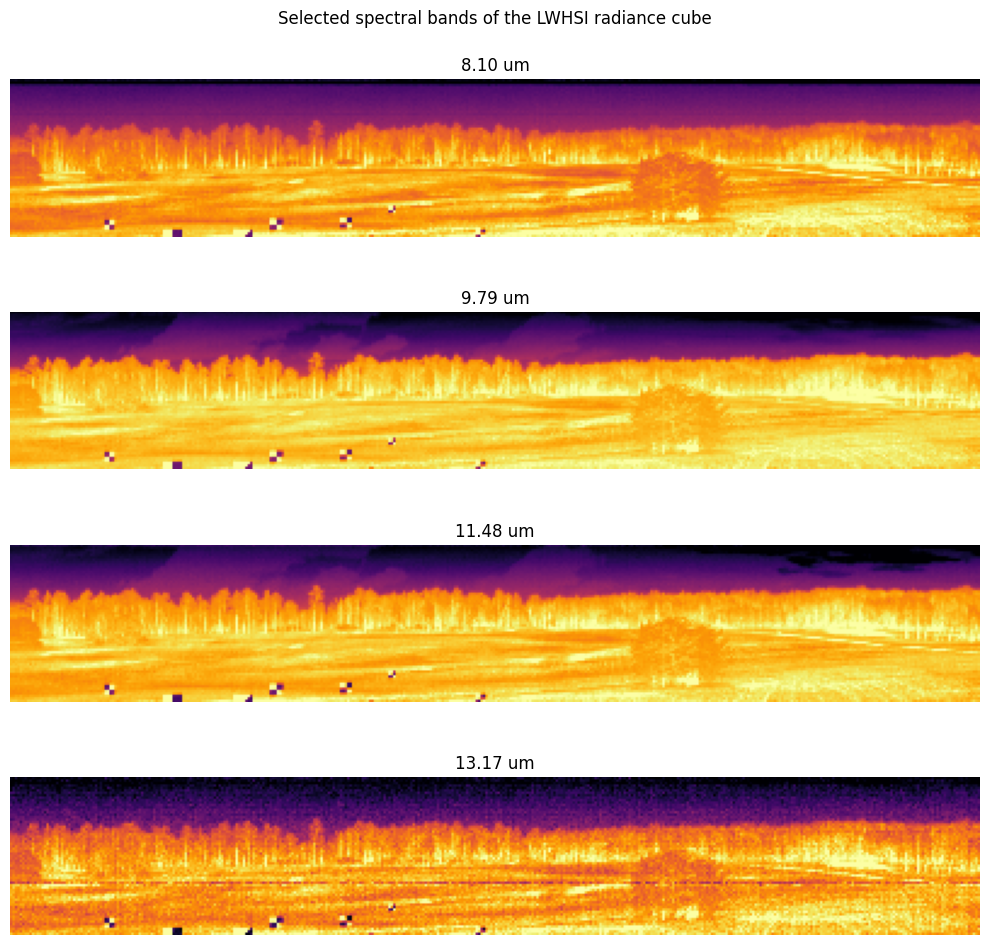

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import spectral.io.envi as envi
import glob

def robust_image(image, low=2, high=98):
    """Normalize an image for display using percentiles."""
    lo, hi = np.percentile(image, [low, high])
    return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)

hdr_files = glob.glob('/content/**/*.hdr', recursive=True)
if not hdr_files:
    raise FileNotFoundError(".hdr files not found")

# There's four different images, you can check them by replacing the idx value between 0-3
idx = 1

if(idx<0 or idx>3):
  print("Index out of range, using 0 as default")
  idx=0

img = envi.open(hdr_files[idx])
radiance_hsi = img.load()

if hasattr(img, 'bands') and 'wavelength' in img.metadata:
    wavelengths_um = [float(w) for w in img.metadata['wavelength']]
else:
    num_bandas = radiance_hsi.shape[2]
    wavelengths_um = np.linspace(8.0, 12.0, num_bandas)

band_indices = np.linspace(0, len(wavelengths_um) - 1, 4, dtype=int)
plot_stride = 4

fig, axes = plt.subplots(len(band_indices), 1, figsize=(10, 10))
axes = axes.ravel()

for ax, band_index in zip(axes, band_indices):
    band_image = radiance_hsi[::plot_stride, ::plot_stride, band_index]
    im = ax.imshow(robust_image(band_image), cmap='inferno')
    ax.set_title(f'{wavelengths_um[band_index]:.2f} um')
    ax.axis('off')

fig.suptitle('Selected spectral bands of the LWHSI radiance cube')
plt.tight_layout()
plt.show()


Elegimos los pixeles que queramos plotear (Las imágenes son 260x1600x256)

In [ ]:
selected_pixels = [
    (180, 1050, 1, "Pixel 1"),
    (40, 250, 2, "Pixel 2"),
    (250, 370, 3, "Pixel 3"),
    (252, 273, 4, "Pixel 4")
]

selected_pixels

[(180, 1050, 1, 'Pixel 1'),
 (40, 250, 2, 'Pixel 2'),
 (250, 370, 3, 'Pixel 3'),
 (252, 273, 4, 'Pixel 4')]

Usamos la función del blackbody

In [ ]:
MICROFLICK_PER_W_M2 = 100.0

def blackbody_radiance(wavelenghts_um, temperature_k):
    """Planck blackbody spectral radiance for all bands, in uW / (sr um cm^2)."""
    h = 6.62607015e-34
    c = 299792458.0
    k = 1.380649e-23

    wavelength_m = wavelengths_um * 1e-6

    x = (h * c) / (wavelength_m * k * temperature_k)

    radiance_w_m2_sr_um = (2.0 * h * c**2) / (wavelength_m**5 * np.expm1(x)) * 1e-6
    radiance_microflicks = radiance_w_m2_sr_um * MICROFLICK_PER_W_M2

    return radiance_microflicks.astype(np.float32)

Elegimos el parámetro de la temperatura en Kelvin

In [ ]:
temperature_k = 300

/tmp/ipykernel_1482/4125044562.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)


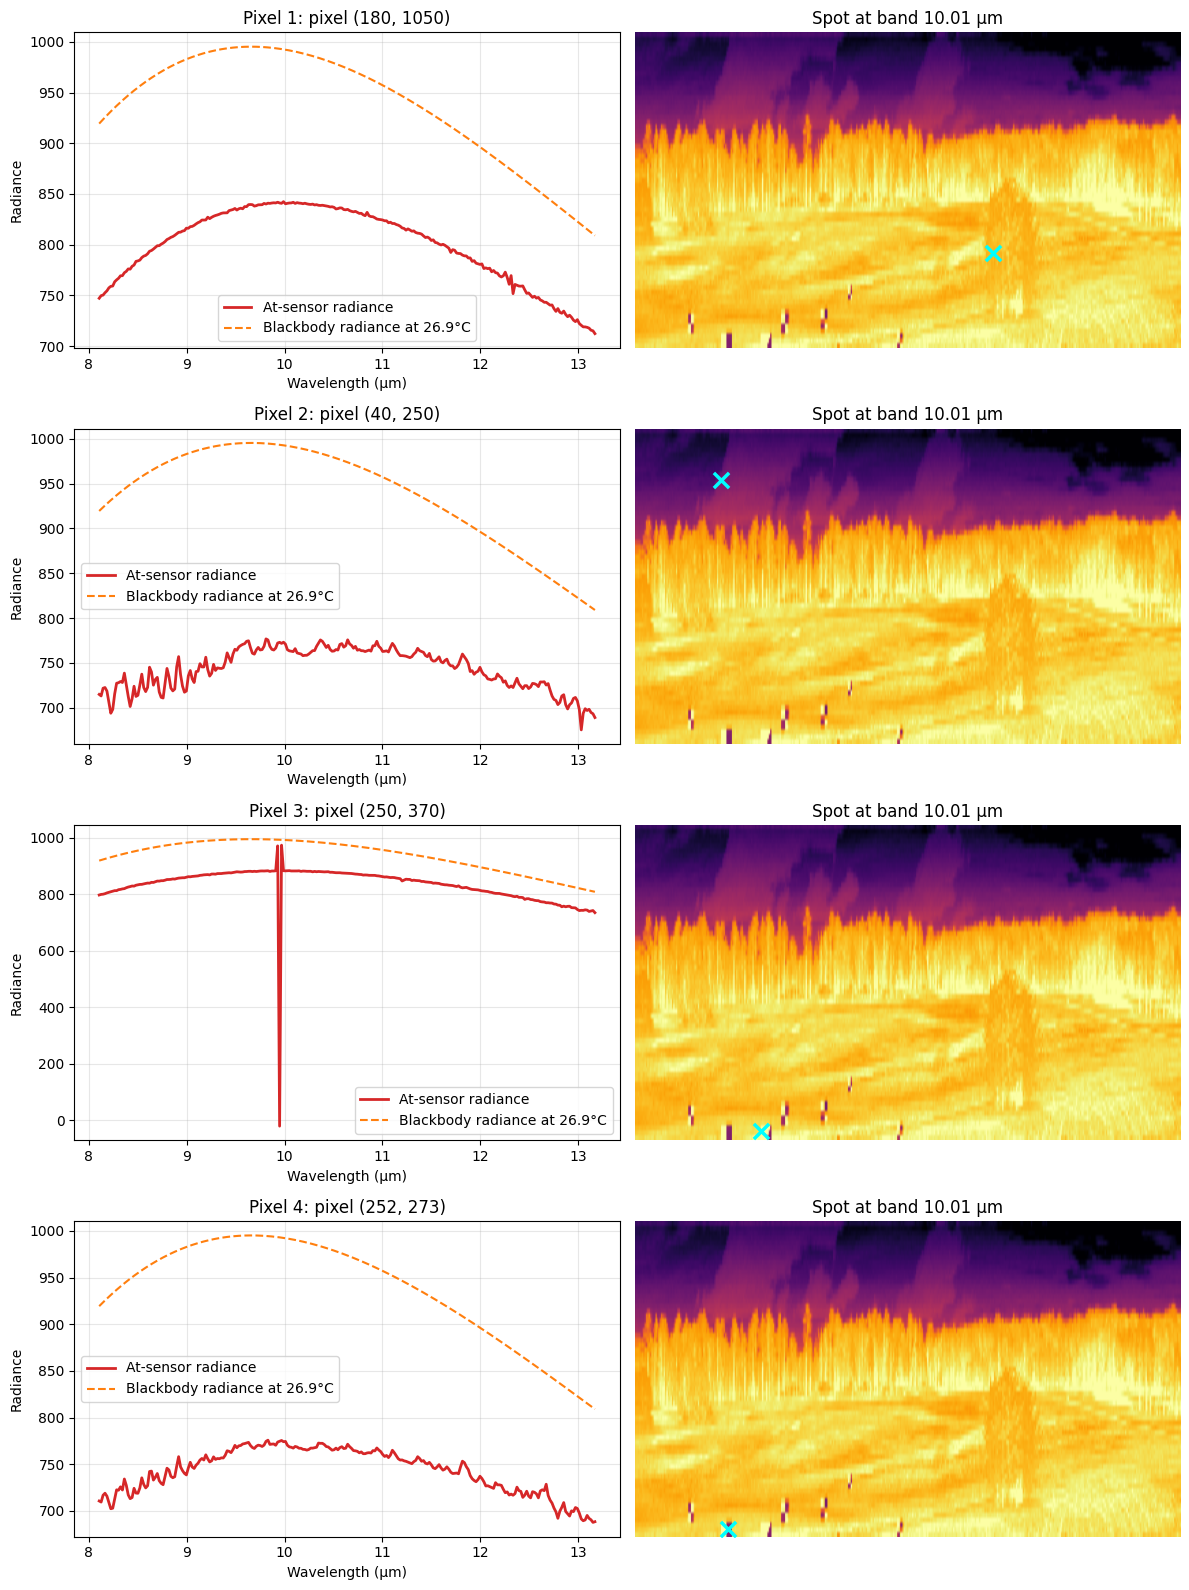

In [ ]:
wavelengths_um = np.array(wavelengths_um)
blackbody_curve=blackbody_radiance(wavelengths_um, temperature_k)

context_band = int(np.argmin(np.abs(wavelengths_um - 10.0)))
context_image = robust_image(radiance_hsi[::plot_stride, ::plot_stride, context_band])

fig, axes = plt.subplots(len(selected_pixels), 2, figsize=(12, 4 * len(selected_pixels)))
if len(selected_pixels) == 1:
    axes = axes[None, :]

for row_axes, (row, col, material_id, material_name) in zip(axes, selected_pixels):
    ax_spec, ax_img = row_axes
    ax_spec.plot(wavelengths_um, radiance_hsi[row, col, :].flatten(), color='tab:red', linewidth=2, label='At-sensor radiance')
    ax_spec.plot(wavelengths_um, blackbody_curve, color='tab:orange', linestyle='--', linewidth=1.5,
                 label=f'Blackbody radiance at {temperature_k-273.15:.1f}°C')
    ax_spec.set_title(f'{material_name}: pixel ({row}, {col})')
    ax_spec.set_xlabel('Wavelength (µm)')
    ax_spec.set_ylabel('Radiance')
    ax_spec.grid(True, alpha=0.3)
    ax_spec.legend()
    ax_img.imshow(context_image, cmap='inferno', aspect='auto')
    ax_img.scatter(col / plot_stride, row / plot_stride, s=120, marker='x', color='cyan', linewidths=2.5)
    ax_img.set_title(f'Spot at band {wavelengths_um[context_band]:.2f} µm')
    ax_img.axis('off')

plt.tight_layout()
plt.show()